# Astr 324, Spring 2026, University of Washington


# Week 5:  Introduction to Markov Chain Monte Carlo  

#### This notebook is available from [github](https://github.com/uw-astr-324/astr-324-s26/blob/main/lectures/Week5.ipynb).

### Resources for this notebook include:
- [Textbook](https://press.princeton.edu/books/hardcover/9780691198309/statistics-data-mining-and-machine-learning-in-astronomy) Chapters 5 and 8.  
  
  
### For further reading

These lectures have been adapted from a range of different materials including 
- [Thomas Wiecki: ``MCMC sampling for dummies by Thomas Wiecki"](http://twiecki.github.io/blog/2015/11/10/mcmc-sampling/)
- [Probabilistic Programming and Bayesian Methods for Hackers by Cam Davidson Pilon](http://nbviewer.jupyter.org/github/CamDavidsonPilon/Probabilistic-Programming-and-Bayesian-Methods-for-Hackers/blob/master/Chapter1_Introduction/Ch1_Introduction_PyMC2.ipynb)
- [Abraham Flaxman's (UW) discussion of MCMC](https://healthyalgorithms.com/)

### For those who want to dive deep:
- [Andrieu et al. ``An Introduction to MCMC for Machine Learning" (includes a few pages of history)"](http://www.cs.princeton.edu/courses/archive/spr06/cos598C/papers/AndrieuFreitasDoucetJordan2003.pdf)

<a id='toc'></a>

# This notebook includes:
- [Introduction to MCMC](#introduction-to-mcmc)
- [Non-linear Regression with MCMC](#non-linear-regression-with-mcmc)

### Software needed

For detailed examples, we will be using [PyMC](https://www.pymc.io/welcome.html)

- pip install git+https://github.com/pymc-devs/pymc

- also [emcee](https://emcee.readthedocs.io/en/stable/)

- and for visualization, we will need: pip install corner 

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm, cauchy
import scipy.stats as stats  

# MCMC library
import pymc as pm
# analysis and visualization helper for pymc
import arviz as az

# for visualization of multi-dimensional posteriors
import corner 

%matplotlib inline

g++ not available, if using conda: `conda install gxx`


## test PyMC installation: 

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma]


C:\Users\jacke\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\
Python313\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 22 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,9.984,0.21,9.7,10,3901,2871,1.00,0.0034,0.0023
sigma,2.071,0.15,1.8,2.3,4126,2570,1.00,0.0024,0.0018


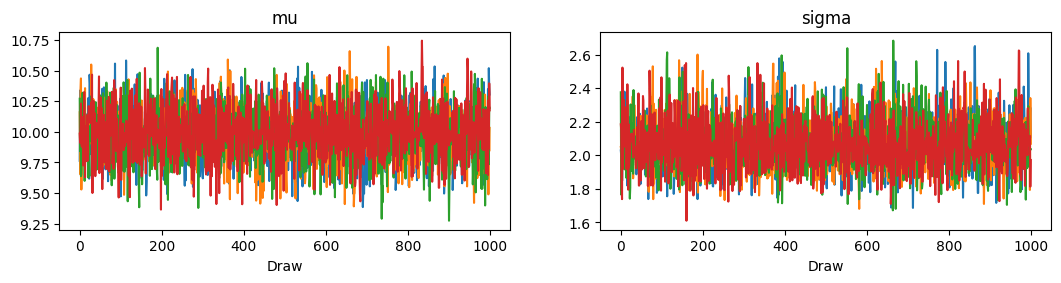

In [2]:
## this is a simple test: find mu and sigma for a sample drawn from Gaussian distribution
# generate data
N = 100
mu_0 = 10.0
sigma_0 = 2.0
# data to fit below
y = np.random.normal(loc=mu_0, scale=sigma_0, size=N)

# run MCMC
nsamples = 1000

with pm.Model() as model:
    # guess that -20 < mu < 20 and assume uniform prior
    mu = pm.Uniform('mu', lower=-20, upper=20)
    # guess that 0 < sigma < 10 and assume uniform prior
    sigma = pm.Uniform('sigma', lower=0, upper=10)
    
    # model for observed values: normal distribution parametrized with mu and sigma
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

    # sample (search) for best mu and sigma in agreement with the "observed" values
    trace = pm.sample(nsamples, random_seed=123, progressbar=True)

# plotting + summary (ArviZ)
az.plot_trace(trace)
az.summary(trace)

**az.plot_trace** provides the timeseries of the parameter values from the chain (left: mu, right: sigma)

In [3]:
trace

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:  (chain: 4, draw: 1000)
│       Coordinates:
│         * chain    (chain) int64 32B 0 1 2 3
│         * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│       Data variables:
│           mu       (chain, draw) float64 32kB 9.764 10.34 10.08 ... 9.861 10.4 10.18
│           sigma    (chain, draw) float64 32kB 2.029 1.999 2.221 ... 2.115 1.813 1.972
│       Attributes:
│           created_at:                 2026-05-05T17:47:17.734261+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  5.28.0+86.g151672a7
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              21.711713790893555
│           tuning_steps:               1000
├── Group: /sample_stats
│       Dimensions:                (chain: 4, draw: 1000)
│       Coordinates:
│         * chain                  (chain) int64 32B 0 1 2 3
│         * draw                   (draw) int64 8kB 0 1 2 3 4 5 ... 995 996 997 998 999
│       Data variables: (12/18)
│           n_steps                (chain, draw) float64 32kB 1.0 3.0 3.0 ... 3.0 1.0
│           process_time_diff      (chain, draw) float64 32kB 0.0 0.0 0.0 ... 0.0 0.0
│           reached_max_treedepth  (chain, draw) bool 4kB False False ... False False
│           energy                 (chain, draw) float64 32kB 217.6 220.0 ... 219.1
│           acceptance_rate        (chain, draw) float64 32kB 1.0 0.5939 ... 0.3936 1.0
│           diverging              (chain, draw) bool 4kB False False ... False False
│           ...                     ...
│           perf_counter_start     (chain, draw) float64 32kB 2.817e+03 ... 2.82e+03
│           divergences            (chain, draw) int64 32kB 0 0 0 0 0 0 ... 0 0 0 0 0 0
│           tree_depth             (chain, draw) int64 32kB 1 2 2 2 2 2 ... 1 2 2 2 2 1
│           index_in_trajectory    (chain, draw) int64 32kB 1 -2 -1 -3 3 ... -1 3 2 1 1
│           max_energy_error       (chain, draw) float64 32kB -0.1933 1.026 ... -1.694
│           smallest_eigval        (chain, draw) float64 32kB nan nan nan ... nan nan
│       Attributes:
│           created_at:                 2026-05-05T17:47:17.756544+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  5.28.0+86.g151672a7
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              21.711713790893555
│           tuning_steps:               1000
└── Group: /observed_data
        Dimensions:      (y_obs_dim_0: 100)
        Coordinates:
          * y_obs_dim_0  (y_obs_dim_0) int64 800B 0 1 2 3 4 5 6 ... 93 94 95 96 97 98 99
        Data variables:
            y_obs        (y_obs_dim_0) float64 800B 7.439 10.08 8.784 ... 9.687 10.36
        Attributes:
            created_at:                 2026-05-05T17:47:17.763589+00:00
            creation_library:           ArviZ
            creation_library_version:   1.1.0
            creation_library_language:  Python
            inference_library:          pymc
            inference_library_version:  5.28.0+86.g151672a7
            sample_dims:                []

<a id='intromcmc'></a>
## Introduction to MCMC
[Go to top](#toc)


### Problem statement

**Assume that we have a (pseudo-)random number generator (return a number from a uniform distribution in the range 0 to 1). How can we use this number generator to generate a set of numbers from an arbitrary, typically multi-dimensional distribution (that we know how to compute)?**

##### Highly recommended supplemental background reading:
- [Thomas Wiecki: ``MCMC sampling for dummies by Thomas Wiecki"](http://twiecki.github.io/blog/2015/11/10/mcmc-sampling/)



### Here MCMC stands for Markov Chain Monte Carlo

In statistics, Markov chain Monte Carlo (MCMC) methods comprise a class of algorithms for **sampling from a probability distribution.** 

By constructing a Markov chain that has the desired distribution as its equilibrium distribution, one can obtain a sample of the desired distribution by recording states from the chain. The more steps are included, the more closely the distribution of the sample matches the actual desired distribution. 

Various algorithms exist for constructing chains, including the Metropolis–Hastings algorithm. For more details,
see Chapter 5 in the textbook and 
https://en.wikipedia.org/wiki/Markov_chain_Monte_Carlo




Monte Carlo is a city in Europe, in the Principality of Monaco (of Grace Kelly fame)... and they are known for gambling. A family of random sampling methods was named after Monte Carlo in order to keep the method secret (because it was invented and used for nuclear weapons design in the U.S. around and after World War II). With the advent of computers, Monte Carlo methods, such as Monte Carlo integration and Monte Carlo statistical tests, became hugely important.


![monaco](figures/monacoMap.jpg)
![monaco](figures/montecarlophoto.jpg)





### Reminder:

**The Bayesian Statistical Inference process** is:
* formulate the likelihood, $p(D\,|\,M,\theta,I)$
* chose a prior $p(M,\theta\,|\,I)$, which incorporates *other information beyond the data in $D$*
* determine the posterior pdf, $p(M,\theta \,|\,D,I)$
* search for the model parameters that maximize $p(M,\theta \,|\,D,I)$ 
* quantify the uncertainty of the model parameter estimates (credible region)
* to get Bayes factor, we integrate $p(D\,|\,M,\theta,I)*p(\theta\,|M,\,I)$ over the parameter space $d\theta$.

### Definition of the general problem

**To find the maximum of a multi-dimensional function (e.g. likelihood or Bayesian posterior pdf)
we need a better method than the brute force grid search!**

For example, if we could generate a **sample** of  {$\mu_𝑖,\sigma_𝑖$}  drawn from the posterior pdf for  𝜇  and  𝜎 , we could simply get posterior pdf for  𝜇  and  𝜎  by plotting histograms of  𝜇  and  𝜎  (similar to the "𝜇-𝜎" figure from Week 3 lecture). As simple as that!

But how can we get such samples? **By using computers!** And MCMC!

First we'll say a few words about Monte Carlo in general, and then we'll talk about a special kind of Monte Carlo called Markov Chain Monte Carlo.

What we want to be able to do is to evaluate multi-dimensional 
($\theta$ is a k-dimensional vector) integrals of the form 
$$ I = \int g(\theta) \, p(\theta) \, d\theta,$$
where for simplicity posterior pdf is described as
$$ p(\theta) \equiv p(M,\theta \,|\,D,I) \propto p(D\,|\,M,\theta,I)\,p(M,\theta\,|\,I). $$

For example:

1) **Marginalization**: if the first $P$ elements of $\theta$ are the sought
after model parameters, and the next $k-P$ parameters are nuisance 
parameters, when marginalizing $p(\theta)$ over nuisance parameters
we have $g(\theta) = 1$ and we integrate over space spanned by $k-P$ 
nuisance parameters. 

2) **Point estimates** for the posterior: if we want the mean (expectation value) of a model
parameter $\theta_m$, then $g(\theta) = \theta_m$ and we integrate over
all model parameters. 

3) **Model comparison**: here $g(\theta) = 1$ and we integrate over all model
parameters. 

## Monte Carlo Methods 

What you need is a computer that can generate (pseudo)random numbers and then you
solve a lot of hard problems. Let' start with an easy problem of one-dimensional
numerical integration.

Assume that you can generate a distribution of M random numbers $\theta_j$ uniformly sampled 
within the integration volume V. Then our integral can be evaluated as 
$$ I = \int g(\theta) \, p(\theta) \, d\theta = \frac{V}{M} \sum_{j=1}^M g(\theta_j) \, p(\theta_j).$$
    
Note that in 1-D we can write a similar expression 
$$ I = \Delta \, \sum_{j=1}^M g(\theta_j) \, p(\theta_j) = \Delta \, \sum_{j=1}^M f(\theta_j).$$

where $ f(\theta) = g(\theta) \, p(\theta) $, and it is assumed that the values
$\theta_j$ are sampled on a regular grid with the step $\Delta = V/M$ ($V$ here is the
length of the sampling domain). This expression is the simplest example of
**numerical integration** ("rectangle rule", which amounts to approximating $f(\theta)$
by a piecewise constant function).

The reason why we expressed $f(\theta)$
as a product of $g(\theta)$ and $p(\theta)$ is that, as we will see shortly,
we can generate a sample drawn from $p(\theta)$ (instead of sampling on a 
regular grid), and this **greatly improves the performance of numerical integration**.

### A simple example: numerical integration with Monte Carlo

One of the simplest numerical integration methods is generic Monte Carlo. We generate a random set of  M values  $\theta$,  uniformly sampled within the integration volume  $V(\theta)$ as ${ I \approx { V(\theta) \over M} \sum_{j=1}^M g(\theta_j) \, p(\theta_j). }$ This method is very inefficient when the integrated function greatly varies within the integration volume, as is the case for the posterior pdf. This problem is especially acute with high-dimensional integrals (the so-called "curse of dimensionality").

Let's estimate the value of $\pi$ using numerical intergration (we assume that we know that the area of circle is $\pi$*radius$^2$).

#### Algorithm

- draw two numbers, call them x and y, from uniform distribution in the range 0 to 1
- interpret them as coordinates and count instances when $x^2 + y^2 < 1$ (that is, the location is within unit circle)
- multiply the fraction of these points by 4: the result is a numerical estimate of $\pi$

Let's see how the accuracy of this algorithm improves with the number of draws $M$

Note: this is **not** the best estimator! 

fractional integration error for pi:
M:  100 0.005859240340778607
M:  1000 0.002039521706573115
M:  10000 0.0015255490186853722
M:  100000 0.0008507320599756971


C:\Users\jacke\AppData\Local\Temp\ipykernel_16376\4193029984.py:10: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  plt.plot(x, y, '.k', markersize=3, c='blue')
C:\Users\jacke\AppData\Local\Temp\ipykernel_16376\4193029984.py:11: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  plt.plot(x[r2<1], y[r2<1], '.k', markersize=3, c='red')


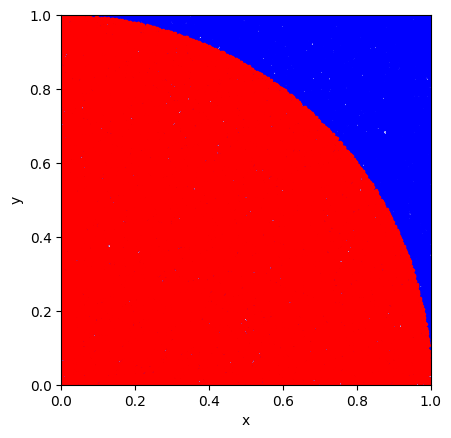

In [4]:
print ("fractional integration error for pi:")
for M in [100, 1000, 10000, 100000]:
    x = stats.uniform(0, 1).rvs(M)
    y = stats.uniform(0, 1).rvs(M)
    r2 = x*x+y*y 
    numericalPi = 4.0*np.size(x[r2<1])/M
    print ('M: ', M, np.abs((np.pi-numericalPi)/np.pi))

fig, ax = plt.subplots(subplot_kw=dict(aspect='equal'))
plt.plot(x, y, '.k', markersize=3, c='blue')
plt.plot(x[r2<1], y[r2<1], '.k', markersize=3, c='red')
ax.axis([0, 1, 0, 1])
plt.xlabel('x')
plt.ylabel('y')
plt.show()

##  Markov Chain Monte Carlo

The modern version of the Markov Chain Monte Carlo method was invented in the late 1940s by Stanislaw Ulam, while he was working on nuclear weapons projects at the Los Alamos National Laboratory. The name Monte Carlo
was given to the method by Nick Metropolis, who then invented the Metropolis sampler, which evolved into
one of the most famous MCMC algorithms, the Metropolis-Hastings algorithm. 


A number of methods exist that are much more efficient than generic Monte Carlo integration. 
The most popular group of techniques is known as Markov Chain Monte Carlo (MCMC) . 

MCMC returns a sample of points, or **chain**, from the k-dimensional parameter space, with 
a distribution that is **asymptotically proportional** to $p(\theta)$. The constant of 
proportionality is not important in the first class of problems listed above. In model 
comparison problems, the proportionality constant must be known and we will return to this 
point later.


Algorithms for generating Markov chains are numerous and greatly vary in complexity
and applicability. Many of the most important ideas were generated in physics, especially
in the context of statistical mechanics, thermodynamics, and quantum field theory.


### What is a Markov process or chain?

A Markov process is defined as a sequence of random variables where a parameter depends 
*only* on the preceding value.  Such processes are "memoryless".  
 
Mathematically, we have
$$p(\theta_{i+1}|\{\theta_i\}) = p(\theta_{i+1}|\,\theta_i).$$


Think of $\theta$ as a vector in multidimensional space, and a realization of the chain represents a path through this space. 

For **equilibrium**, or a stationary distribution of positions, it is necessary that the transition probability is symmetric:
$$    p(\theta_{i+1}|\,\theta_i) = p(\theta_i |\, \theta_{i+1}). $$


This is called the **detailed balance** or reversibility condition (i.e. the probability of a jump between two points does not depend on the direction of the jump).


The use of resulting chains to perform Monte Carlo integration is called Markov Chain Monte Carlo (MCMC).
Given such a chain of length M, the integral can be estimated as
$$ I = \int g(\theta) \, p(\theta) \, d\theta = \frac{1}{M} \sum_{j=1}^M g(\theta_j).$$

Again, here **the values of $\theta$ are not sampled uniformly from the volume**;
they are sampled **proportionally** to $p(\theta)$! 

Note that there is no $p(\theta_j)$ term next to $g(\theta_j)$ because the proper weighting in the sum is taken care of by the sample itself! 

As a simple example, to estimate the expectation value for $\theta_1$ (i.e., $g(\theta)=\theta_1$),
we simply take the mean value of all $\theta_1$ in the chain.

Given a Markov chain, quantitative description of the posterior pdf
becomes a **density estimation problem**. To visualize the posterior pdf
for parameter $\theta_1$, marginalized over all other parameters, $\theta_2, \ldots, \theta_k$,
we can construct a **histogram** of all $\theta_1$ values in the chain, and normalize its integral
to 1. To get a MAP (maximum a posterori) estimate for $\theta_1$, we  find the maximum of this marginalized pdf.

In order for a Markov chain to reach a stationary distribution proportional to $p(\theta)$,
the probability of arriving at a point $\theta_{i+1}$ must be proportional to $p(\theta_{i+1})$,
$$ p(\theta_{i+1}) = \int  T(\theta_{i+1}|\theta_i)  \,   p(\theta_i) \,    d \theta_i, $$
where the transition probability $T(\theta_{i+1}|\theta_i)$ is called the jump kernel or
transition kernel (and it is assumed that we know how to compute $p(\theta_i)$).

This requirement will be satisfied when the transition probability satisfies the detailed
balance condition
$$ T(\theta_{i+1}|\theta_i)  \,  p(\theta_i) = T(\theta_i|\theta_{i+1})  \,  p(\theta_{i+1}). $$




##  Markov Chain Monte Carlo

How do we build the chain? Need to choose how far we will be allowed to move at each step. Need to decide whether we will accept the move.

**Various MCMC algorithms differ in their choice of transition kernel.**

The most classic approach is the **The Metropolis-Hastings algorithm** 

**The Metropolis-Hastings algorithm** adopts acceptance probability
$$ p_{\rm acc}(\theta_i,\theta_{i+1}) = { p(\theta_{i+1}) \over p(\theta_i) }, $$
where the proposed point $\theta_{i+1}$ is drawn from an *arbitrary* symmetric density distribution $K(\theta_{i+1}\,|\,\theta_i)$. A Gaussian distribution centered on 
$\theta_i$ is often used for $K(\theta_{i+1}|\theta_i)$.

** When $\theta_{i+1}$ is rejected, $\theta_i$ is added to the chain instead. **

The original Metropolis algorithm is based on a symmetric proposal distribution,
$K(\theta_{i+1}|\theta_i) =  K(\theta_i|\theta_{i+1})$, which then cancels out from
the acceptance probability. **In this case, $\theta_{i+1}$ is always accepted if
$p(\theta_{i+1}) > p(\theta_i)$, and if not, then it is accepted with a probability**
$p(\theta_{i+1})/p(\theta_i)$ < 1.


This algorithm guarantees that the chain will reach an equilibrium, or stationary, distribution, and it will approximate a sample drawn from $p(\theta)$! 
 

##  Markov Chain Monte Carlo

**In summary, the Metropolis-Hastings algorithm consists of these steps:**

1) given $\theta_i$ and $K(\theta_{i+1}|\theta_i)$, draw a proposed value for $\theta_{i+1}.$ 

2) compute acceptance probability $p_{\rm acc}(\theta_i,\theta_{i+1})$.

3) draw a random number between 0 and 1 from a uniform distribution; if it is smaller than
   $p_{\rm acc}(\theta_i,\theta_{i+1})$, then accept $\theta_{i+1}$.
   
4) if $\theta_{i+1}$ is accepted added it to the chain, if not, add $\theta_{i}$ to the chain.

5) use the chain (of $\theta$ values) for inference; e.g. a histogram of $\theta$ is
  an estimator of the posterior pdf for $\theta$, $p(\theta)$, and the expectation value for 
  $\theta$ can be computed from 
  $$ I = \int g(\theta) \, p(\theta) \, d\theta = \frac{1}{M} \sum_{j=1}^M \theta_j.$$

where M is the number of elements in the chain (e.g. 
the expectation value for $\theta$ is simply the mean value of chain elements). 
  
  

### A simple example

Before looking at the  Metropolis-Hastings algorithm in more detail, let's
look at a very simple example of MCMC:
- there are only 10 possible states (think of digits 0-9)
- we are given the target probabilities for these states (frequency of each digit): $t_0, t_1..., t_9$.
- we want to generate a sample of N digit values, $n_0, n_1,...,n_9$, whose distribution 
   $p_i = n_i/\Sigma n$ (n.b. $ \Sigma n = N$) approaches the target distribution $t$ (that is, 
   $p_0 \approx t_0$, $p_1 \approx t_1$, etc). In other words, 
   we want the histogram of that sample to have the same shape as the target distribution.
- for simplicity, we draw the next digit randomly and uniformly from all 10 possibilities
- if we accept all the new proposed digits, we'll end up with a uniform distribution (because
  that's how we are drawing the new values)
- hence, **the key is to reject some proposed digits so that the remaining ones resemble the desired
  target distribution**


The last condition, accepting B with a probability $T(B|A)=p(B)/p(A)$, **guarantees**
that we will eventually arrive to a stationary distribution, and that distribution 
will converge to the input desired distribution. 
  



### An even simpler example! 

Before going to the 10-states example, let's consider for a moment **a two-state example,
with states A and B**. It would be a stretch to call it an MCMC example, but it does
address one of the key aspects of MCMC: how to set the rejection (or acceptance)
probability for a new "proposal".

Let's assume that the target probabilities are $t(A)$ and $t(B)$, with $t(A) > t(B)$ 
without a loss of generality (and of course $t(A) + t(B)=1$). Say, $t(A)=0.9$ and
$t(B)=0.1$. We want a sample of $N$ values that can be either A or B, with $t(A)N$ 
in state A and $t(B)N$ in state B.

We begin by drawing a sample of $N$, say $N=1000$, random values that can be either 
A or B. We expect that we will have about N/2 values of A and about N/2 values of B. 
This is **not** what we want - we want to have 900 A values and 100 B values, not
500 and 500!. Therefore, we need to **take a fraction of proposed B values and
re-assign them to A** (in other words, *reject* them from the proposed B subset). 

How do we choose them? 

<img src="figures/digits.png" alt="Drawing" style="width: 600px;"/>


In a steady state described by the target probabilities, we expect that out of N/2 
proposed B values, about $t(A)N/2$ were drawn when the system was in A state, and 
about $t(B)N/2$ when the system was in B state. Hence, in the former case the system 
is in the more probable A state and the proposal is to move to the less probable B state. 
Again, if we accept all proposals, we will not end up with the desired distribution. 
Instead, we need to **reject** a fraction $x_A$ of these $t(A)N/2$ proposals to adopt 
(the less probable) B state and thus accept (stick with) $x_At(A)N/2$ current A states. 

As a result, we will have a total of $\left(N/2 + x_At(A)N/2\right)$ A states, and we want it 
to be equal to $t(A)N$. Therefore, we have a condition for the rejection fraction $x_A$:
$$ \frac{N}{2} + x_A\,t(A)\,\frac{N}{2} = t(A)\,N.$$
The solution for the rejection fraction is $x_A = 1 - t(B)/t(A)$, and thus the 
acceptance probability in cases when the proposal is to go from state A to state B
must be 
$$p_{acc}(B|A) =  t(B)/t(A).$$ 
In all other cases (A proposed to go to A, and B proposed
to go to either state), the proposal is always accepted. 

In summary, **the acceptance probability** for the two-state system is 

1) in A, proposed to go to A: accept

2) in A, proposed to go to B: accept in p(B)/p(A) cases

3) in B, proposed to go to A: accept

4) in B, proposed to go to B: accept 


Let's now do the 10-state example!  

In [5]:
## an implementation of the simplest possible MCMC for drawing a sample of 10 states with given probabilities
def doSimpleMCMC(pi, priorIndex, Niter, printStep, plot = 0):
 
    # starting states 
    states = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
    states[priorIndex] += 1
    Nreject = 0

    for i in range(0, Niter):
        ## get index for the proposed new state: completely random from 10 states 
        newind = np.random.randint(low=0, high=10) # a number between 0 and 9 (inclusive) 
        # MCMC rules:
        # if a uniform variate 0-1 larger than pi[newind]/pi[priorIndex], reject proposed newind
        # and otherwise accept it 
        reject = 0
        if (np.random.uniform() > pi[newind]/pi[priorIndex]):
            reject = 1
        # given "reject": 
        if (reject):    
            states[priorIndex] += 1
            Nreject += 1
        else:
            states[newind] += 1
            priorIndex = newind
        # print progress every printStep steps: 
        if (int(i/printStep)*printStep == i):
            prob = 1.0*states / np.sum(states)
            for j in range(0,np.size(prob)):
                prob[j] = float("{0:.2f}".format(prob[j]))  
            print('i=',i,' p=', prob)

    print('      pi', pi)
    print('')
    print('Tried ', Niter, 'and rejected ', Nreject)

    if (plot):
        plotP(pi, states)

    return states

def plotP(pi,states):
    prob = 1.0*states / np.sum(states)

    # plot
    fig, ax = plt.subplots(figsize=(7, 5))

    N = np.size(pi)
    for i in range(0,N):
        plt.plot([i,i+1],[prob[i],prob[i]], c='red')
        plt.plot([i,i+1],[pi[i],pi[i]], '-', c='blue')            
        if (i < (N-1)):
            plt.plot([i+1,i+1],[prob[i],prob[i+1]], c='red')
            plt.plot([i+1,i+1],[pi[i],pi[i+1]], '-', c='blue')

    plt.xlim(0, 10)
    ymax = 1.1*np.max(pi)
    if (np.max(prob)>np.max(pi)):
        ymax = 1.1*np.max(prob)
    plt.ylim(0, ymax)
    plt.xlabel('$N$')
    plt.ylabel(r'$p(N)$')
    plt.title('red: MCMC, blue: target')
    plt.show() 

i= 0  p= [0.5 0.  0.  0.  0.5 0.  0.  0.  0.  0. ]
i= 1  p= [0.33 0.   0.   0.   0.67 0.   0.   0.   0.   0.  ]
i= 2  p= [0.25 0.   0.   0.   0.75 0.   0.   0.   0.   0.  ]
i= 3  p= [0.2 0.  0.  0.  0.6 0.  0.2 0.  0.  0. ]
i= 4  p= [0.33 0.   0.   0.   0.5  0.   0.17 0.   0.   0.  ]
i= 5  p= [0.43 0.   0.   0.   0.43 0.   0.14 0.   0.   0.  ]
i= 6  p= [0.38 0.   0.   0.   0.38 0.   0.12 0.   0.   0.12]
i= 7  p= [0.33 0.   0.   0.   0.33 0.   0.11 0.   0.   0.22]
i= 8  p= [0.3 0.1 0.  0.  0.3 0.  0.1 0.  0.  0.2]
i= 9  p= [0.27 0.09 0.   0.   0.27 0.   0.09 0.   0.09 0.18]
      pi [0.05, 0.1, 0.18, 0.32, 0.15, 0.05, 0.05, 0.02, 0.05, 0.03]

Tried  10 and rejected  2


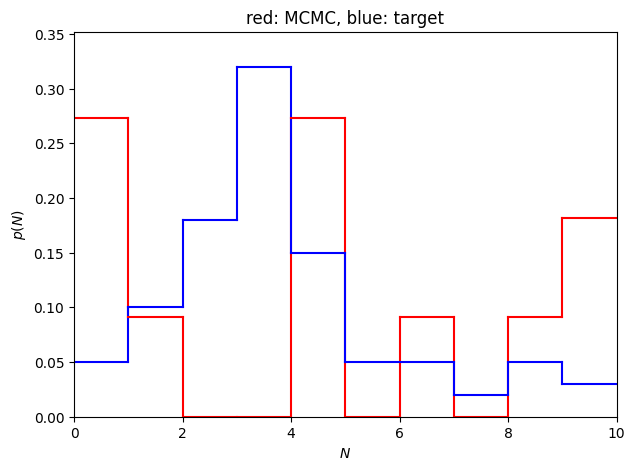

In [6]:
# target distribution for 10 states 
pi = [0.05, 0.10, 0.18, 0.32, 0.15, 0.05, 0.05, 0.02, 0.05, 0.03]
startIndex = 0
Niter = 10
printStep = 1

states = doSimpleMCMC(pi, startIndex, Niter, printStep, 1) 

i= 0  p= [0.5 0.  0.5 0.  0.  0.  0.  0.  0.  0. ]
i= 25  p= [0.11 0.04 0.15 0.26 0.22 0.04 0.07 0.   0.11 0.  ]
i= 50  p= [0.12 0.04 0.1  0.17 0.29 0.08 0.12 0.04 0.06 0.  ]
i= 75  p= [0.08 0.03 0.16 0.25 0.26 0.08 0.08 0.04 0.04 0.  ]
      pi [0.05, 0.1, 0.18, 0.32, 0.15, 0.05, 0.05, 0.02, 0.05, 0.03]

Tried  100 and rejected  47


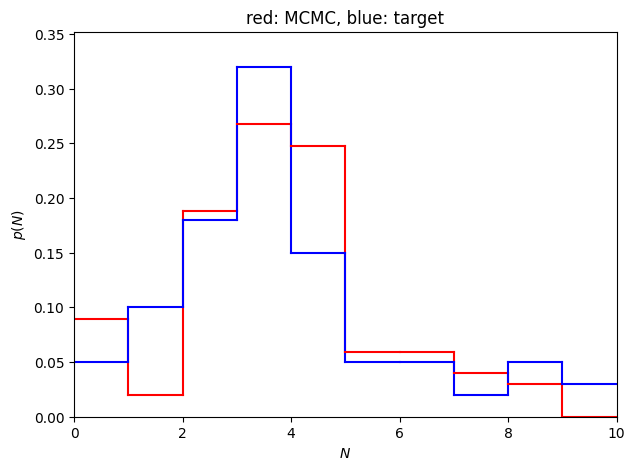

In [7]:
states = doSimpleMCMC(pi, startIndex, 100, 25, 1)

i= 0  p= [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
i= 5000  p= [0.06 0.1  0.18 0.31 0.15 0.05 0.05 0.02 0.05 0.03]
      pi [0.05, 0.1, 0.18, 0.32, 0.15, 0.05, 0.05, 0.02, 0.05, 0.03]

Tried  10000 and rejected  4374


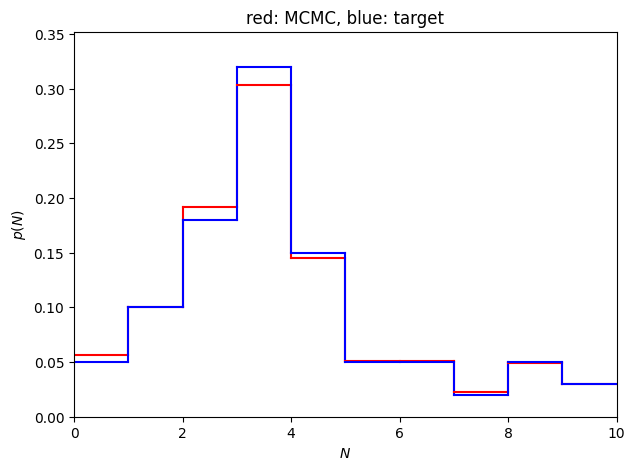

In [8]:
states = doSimpleMCMC(pi, startIndex, 10000, 5000, 1)

### Illustrate Metropolis-Hastings algorithm 

In [9]:
np.random.seed(21)

def Likelihood(x,sigma, data):
    # Gaussian likelihood 
    return np.prod(np.exp(-(data-x)**2/2/sigma**2))

def Prior(x):
    return 1.0/10   # flat: it cancels out and has no effect 

def myPosterior(x, sigma, data):
    return Likelihood(x, sigma, data)*Prior(x)

<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
C:\Users\jacke\AppData\Local\Temp\ipykernel_16376\3466204200.py:24: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('$\mu$')


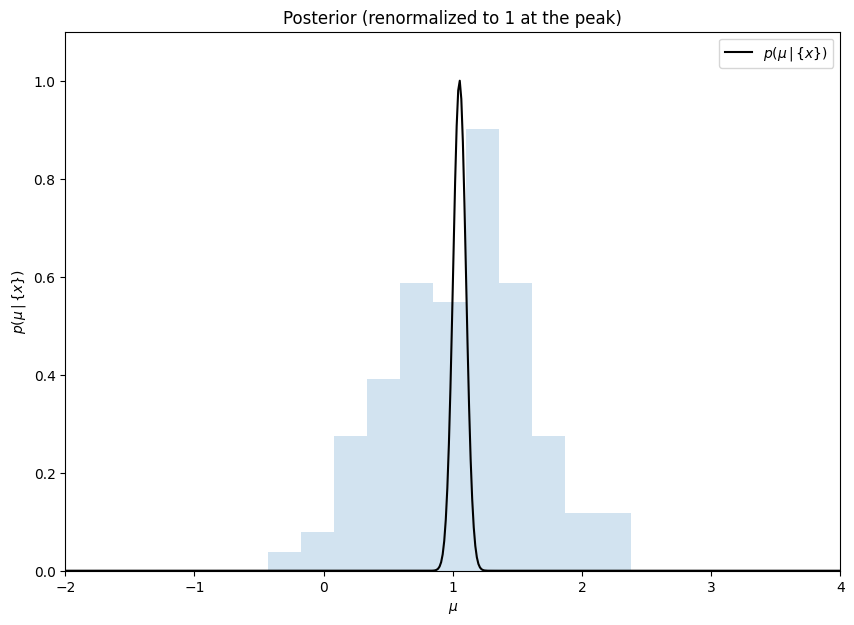

NOTE: Ndata= 100 sigmaData= 0.5 so sigma_mu= 0.05


In [10]:
## generate data
Ndata = 100
mu = 1.0
sigma = 0.5 # assumed known 
data = stats.norm(mu, sigma).rvs(Ndata)

# plot likelihood function 
muMin = mu - 6*sigma
muMax = mu + 6*sigma
muGrid = np.linspace(muMin, muMax, 500)
posterior = 0*muGrid

for j in range(0,np.size(muGrid)):
    posterior[j] = myPosterior(muGrid[j], sigma, data)

posteriorNorm = posterior/np.max(posterior)
# plot
fig, ax = plt.subplots(figsize=(10, 7))
plt.plot(muGrid, posteriorNorm, ls='-', c='black', label=r'$p(\mu\,|\,\{x\})$')
plt.hist(data, bins = 'auto', density=True, histtype = 'stepfilled', alpha=0.2)

plt.xlim(muMin, muMax)
plt.ylim(0, 1.1)
plt.xlabel('$\mu$')
plt.ylabel(r'$p(\mu\,|\,\{x\})$')
plt.title('Posterior (renormalized to 1 at the peak)')
plt.legend()
plt.show() 

sigMu = sigma/np.sqrt(Ndata)
print('NOTE: Ndata=', Ndata, 'sigmaData=', sigma, 'so sigma_mu=', sigMu)

<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
C:\Users\jacke\AppData\Local\Temp\ipykernel_16376\74422674.py:11: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('$\mu$')
C:\Users\jacke\AppData\Local\Temp\ipykernel_16376\74422674.py:12: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('p($\mu^{new}\,|\,$data,I)/($\mu=0.95\,|\,$data,I)')


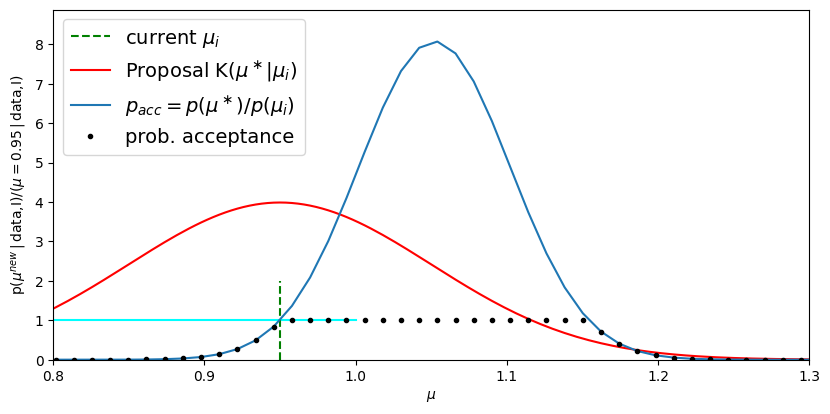

NOTE: we accept if a uniform random number (0-1) falls below the black dotted curve.


In [11]:
## illustrate Metropolis-Hastings algorithm 
muStart = 0.95
posteriorStart = myPosterior(muStart, sigma, data)
pRatio = posterior/posteriorStart

# plot 
fig = plt.figure(figsize=(9, 5))
fig.subplots_adjust(left=0.11, right=0.95, wspace=0.35, bottom=0.18)
ax0 = fig.add_subplot(111)
ax0.axis([0.8, 1.3, 0, 1.1*np.max(pRatio)])
plt.xlabel('$\mu$')
plt.ylabel('p($\mu^{new}\,|\,$data,I)/($\mu=0.95\,|\,$data,I)')
plt.plot([0.8,1.0],[1.0,1.0], '-', c='cyan')
plt.plot([0.95,0.95],[0.0,2.0], '--', c='green', label=r'current $\mu_i$')

# plot proposal distribution
muG = np.linspace(0.0, 2.0,500)
sigmaProp = 0.1
prop = norm(muStart, sigmaProp).pdf(muG) 
plt.plot(muG, prop, c='red', label=r'Proposal K($\mu^\ast|\mu_{i}$)')
plt.plot(muGrid, pRatio, label=r'$p_{acc}=p(\mu^\ast)/p(\mu_i)$')
plt.plot(muGrid[pRatio<1], pRatio[pRatio<1], '.', c='black',label=r'prob. acceptance')
plt.plot(muGrid[pRatio>1], 1+0*muGrid[pRatio>1], '.', c='black')
ax0.legend(loc=2, prop=dict(size=14))
plt.show() 

print('NOTE: we accept if a uniform random number (0-1) falls below the black dotted curve.')

In [13]:
## generate a chain using Metropolis-Hastings algorithm 

# Markov chain 
M = 5000  # the requested number of steps in the chain
chain = np.linspace(0,1,M)
chain[0] = 0.5 # starting position
Pold = myPosterior(chain[0], sigma, data)

# gaussian width for "jumping" from the current position
#    sigmaProp            Na   Nr   Np     
# sigmaProp = 0.03    #  3992 1007 1968   (high acc, long burn-in) 
# sigmaProp = 0.3     #  1043 3956  534   (low acc, short burn-in) 
sigmaProp = 0.10      #  2514 2485 1248        

Na = Nr = Np = 0
# and now sample M times
for i in range(1,M): 
    # 1) generate a new value: a gaussian jump from current value
    Cold = chain[i-1]
    Cnew = stats.norm(Cold, sigmaProp).rvs(1)
    Pnew = myPosterior(Cnew, sigma, data)
    # 2) acceptance condition 
    Pratio = Pnew / Pold  
    if (Pratio > 1): 
        Np += 1   # just a counter, nothing else is done 
    # if we only accept Pratio>1, we'll get a hill-climbing algorithm
    # instead, we'll randomly accept this proposal with probability Pratio 
    randNumber = stats.uniform(0, 1).rvs(1)
    if (randNumber < Pratio):
        # accepting this new proposed value
        chain[i] = Cnew
        Pold = Pnew
        Na += 1
    else:
        # rejecting the proposed value and stickin' with the previous one 
        chain[i] = Cold
        Nr += 1
 
print('NNN(arp): ', Na, Nr, Np)

ValueError: setting an array element with a sequence.

<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
C:\Users\jacke\AppData\Local\Temp\ipykernel_16376\450580685.py:12: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('$\mu$')
C:\Users\jacke\AppData\Local\Temp\ipykernel_16376\450580685.py:13: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('p($\mu\,|\,$data,I)')


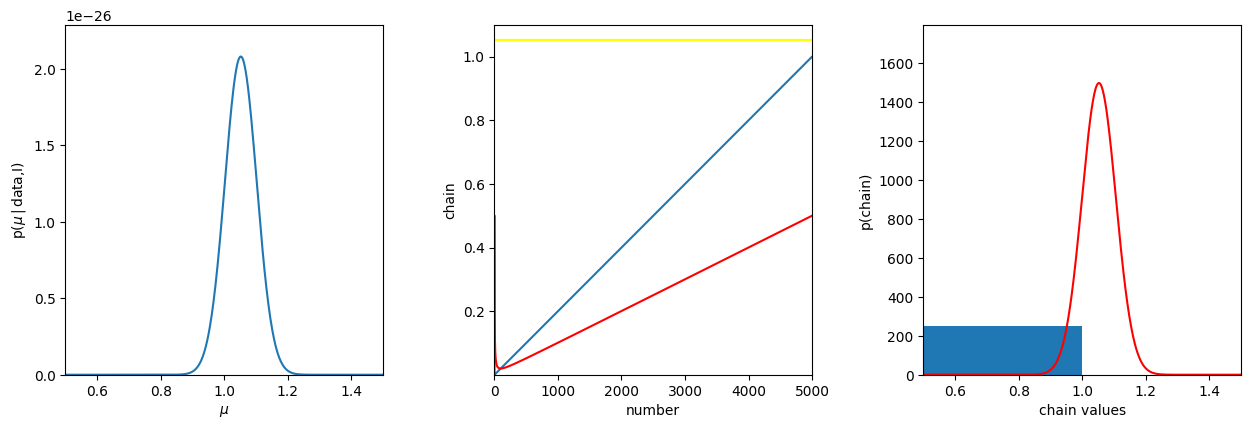

µ=1.052, 𝜎=0.053


In [14]:
# start plot 
fig = plt.figure(figsize=(14, 5))
fig.subplots_adjust(left=0.11, right=0.95, wspace=0.35, bottom=0.18)

ax0 = fig.add_subplot(131)
muGrid = np.linspace(mu-sigma,mu+sigma,500)
posterior = 0*muGrid
for j in range(0,np.size(muGrid)):
    posterior[j] = myPosterior(muGrid[j], sigma, data)
plt.plot(muGrid, posterior)
ax0.axis([mu-sigma, mu+sigma, 0, 1.1*np.max(posterior)])
plt.xlabel('$\mu$')
plt.ylabel('p($\mu\,|\,$data,I)')

ax1 = fig.add_subplot(132)
x = np.linspace(1,M,M)
plt.plot(x, chain)
ax1.axis([0, M, np.min(chain), 1.1*np.max(chain)])
plt.xlabel('number')
plt.ylabel('chain')
# plot running mean: 
meanC = [np.mean(chain[:int(N)]) for N in x]
ax1.plot(x, meanC,c='red') 
ax1.plot(x, 0*x+np.mean(data),c='yellow') 

ax2 = fig.add_subplot(133)
# skip first Nburn samples
Nburn = 1000
Nchain = np.size(chain[x>Nburn])
Nhist, bins, patches = plt.hist(chain[x>Nburn], bins = 'auto', histtype = 'stepfilled')
# plot expectations based on CLT
binwidth = bins[1]-bins[0]
muCLT = np.mean(data)
sigCLT = np.std(data)/np.sqrt(Ndata)
muGrid = np.linspace(mu-sigma,mu+sigma,500)
gauss = Nchain*binwidth*stats.norm(muCLT, sigCLT).pdf(muGrid) 
ax2.plot(muGrid, gauss, c='red') 
ax2.set_ylabel('p(chain)')
ax2.set_xlabel('chain values')
ax2.set_xlim(mu-sigma, mu+sigma)
ax2.set_ylim(0, 1.2*np.max(gauss))

plt.show()
print(f"µ={muCLT:.3f}, 𝜎={sigCLT:.3f}")

## Caveats

Although $K(\theta_{i+1}|\theta_i)$ satisfies a Markov chain requirement that it
must be a function of only the current position $\theta_i$, it takes a number
of steps to reach a stationary distribution from an initial arbitrary position $\theta_0$.
**These early steps are called the "burn-in" and need to be discarded in analysis.**
There is no general theory for finding transition from the burn-in phase to
the stationary phase; several methods are used in practice. Gelman and Rubin
proposed to generate a number of chains and then compare the ratio of
the variance between the chains to the mean variance within the chains (this
ratio is known as the $R$ statistic). For stationary chains, this ratio will
be close to 1.  

When the posterior pdf is multimodal, the simple Metropolis--Hastings algorithm can
become stuck in a local mode and not find the globally best mode within a reasonable
running time. There are a number of better algorithms, such as Gibbs sampling, parallel
tempering, various genetic algorithms, and nested sampling.



<img src="figures/Andrieu4.png" alt="Drawing" style="width: 600px;"/>





### How do we choose the next step

How far should we step (small steps in parameter space or large). This impacts the efficiency of the process but not if we will reach equilibrium. We want our samples to be independent of one another which we can determine with the autocorrelation function - we can then adjust the step size to account for this (e.g. ensure that we reject 50% of the proposed steps)

Other techniques: **NUTS (No-U-Turn Sampler)**, Metropolis, Slice, HamiltonianMC, and BinaryMetropolis

[NUTS](http://arxiv.org/abs/1507.08050) is generally the sampler of choice for continuous parameters (it uses  the gradient of the log posterior-density). See the end of this notebook for animations of different strategies 



In [15]:
from IPython.display import HTML
HTML('<iframe src="https://player.vimeo.com/video/19274900" width="640" height="480" frameborder="0" webkitallowfullscreen mozallowfullscreen allowfullscreen></iframe><p><a href="https://vimeo.com/19274900">Metropolis in the Square</a> from <a href="https://vimeo.com/user3812935">Abraham Flaxman</a> on <a href="https://vimeo.com">Vimeo</a>.</p>')

## Example: a 2-dimensional posterior pdf for location and scale parameters using a sample drawn from Cauchy distribution.

 Exact statement of the problem: 10 samples were drawn from a Cauchy distribution with unknown $\mu$ and $\gamma$. Estimate the posterior of $\mu$ and $\gamma$, assuming uniform prior on $\mu$ and the Jeffreys' prior on $\gamma$.

This can still be solved using the brute force computation on a grid, resulting in: 

<img src="figures/Lcauchy.jpg" alt="Drawing" style="width: 600px;"/>

(this is Figure 5.10 in the textbook).

### Create the mock dataset:

Median:  -0.2625695623133895


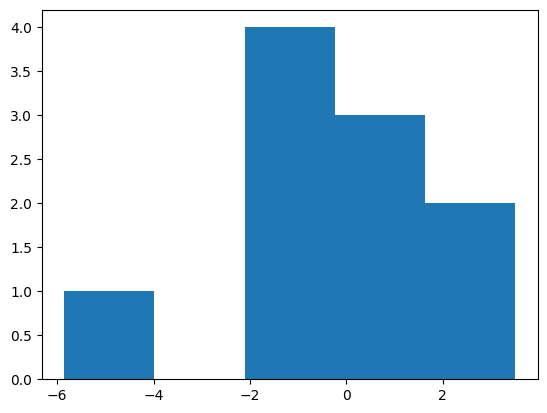

In [16]:
np.random.seed(44)
mu_0 = 0
gamma_0 = 2
xi = cauchy(mu_0, gamma_0).rvs(10)
plt.hist(xi, bins='auto');
print('Median: ', np.median(xi))

Now let's sample the posterior with PyMC.

PyMC requires us to construct the posterior by composing its [built-in distributions](https://docs.pymc.io/api/distributions/continuous.html).

(Note for later: unlike PyMC, **emcee** takes an arbitrary Python function proportional to the log of the posterior)



We start by writing out the Bayes theorem:

$$
p(\mu, \gamma|D) \, d\mu \, d\gamma \propto p(D|\mu, \gamma) \cdot p(\mu, \gamma) \, d\mu \, d\gamma = Cauchy(D|\mu, \gamma) \cdot U(\mu) \cdot J(\gamma) \, d\mu \, d\gamma 
$$

where $U$ is the uniform distribution, and $J$ is the Jeffreys' prior $1/\gamma$.

It's computationally more efficient to use $\log \gamma$ as a variable, in which case $J(\gamma) \rightarrow U(\log \gamma)$. In the new variables, our posterior becomes:

$$
p(\mu, \log \gamma|D) \, d\mu \, d(\log \gamma) \propto Cauchy(D|\mu, \log \gamma) \cdot U(\mu) \cdot U(\log \gamma) \, d\mu \, d(\log \gamma)
$$

We can now go ahead and construct it with PyMC objects. 

Rather than explicitly multiplying the factors above, note how PyMC infers their relationships by via variable names:

In [17]:
## this is SIMPLIFIED code for the textbook figure 5.22, see
## http://www.astroml.org/book_figures/chapter5/fig_cauchy_mcmc.html

# set up our model for mu and log_gamma
with pm.Model():
    mu = pm.Uniform('mu', -5, 5)                  # the two numbers are the right/left limits of the uniform dist.
    log_gamma = pm.Uniform('log_gamma', -10, 10)  # the two numbers are the right/left limits of the uniform dist.

    # set up our likelihood. by setting observed=xi, we tell PyMC3 this is our likelihood.
    x = pm.Cauchy('x', alpha=mu, beta=np.exp(log_gamma), observed=xi)

    # this will start the sampler
    traces = pm.sample(draws=12000, tune=1000, cores=1)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [mu, log_gamma]


C:\Users\jacke\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\
Python313\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 12_000 draw iterations (2_000 + 24_000 draws total) took 9 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


PyMC used its default NUTS sampler. It's very safe, but for some problems can be slow (we'll switch to Metropolis for that reason further below).

Like with emcee, the output is a trace (a chain), but this time a two-dimensional one (for mu and log_gamma):

In [18]:
# compute summary statistics
summary = az.summary(traces)

# best-fit parameters (posterior means)
bf = summary["mean"]

print(bf)

mu           -0.08
log_gamma     0.07
Name: mean, dtype: str


In [19]:
summary

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,-0.08,0.604,-0.9,0.99,13318,12729,1.00,0.0054,0.0045
log_gamma,0.07,0.474,-0.7,0.79,8648,7377,1.00,0.0054,0.0041


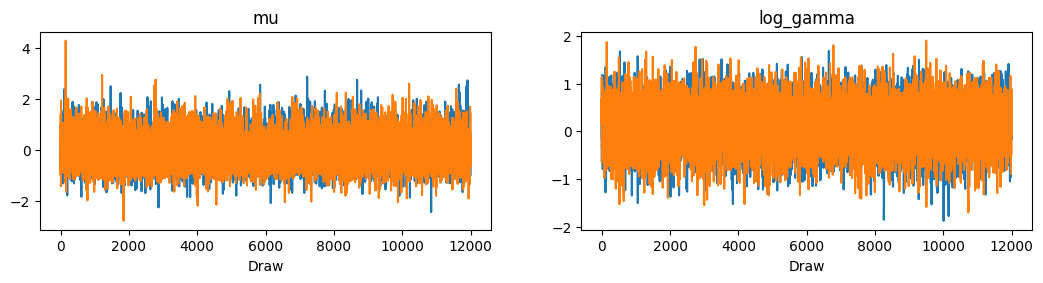

In [20]:
az.plot_trace(traces)

In [21]:
# extract posterior samples correctly
posterior = az.extract(
    traces,
    group="posterior",
    var_names=["mu", "log_gamma"]
)

samples = np.vstack([
    posterior["mu"].values,
    posterior["log_gamma"].values, 
]).T

In [22]:
samples[:,0]

array([-0.74531352,  0.31467652,  0.39144707, ...,  0.19697789,
        1.09965631,  1.42447674], shape=(24000,))

C:\Users\jacke\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\astroML\linear_model\linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


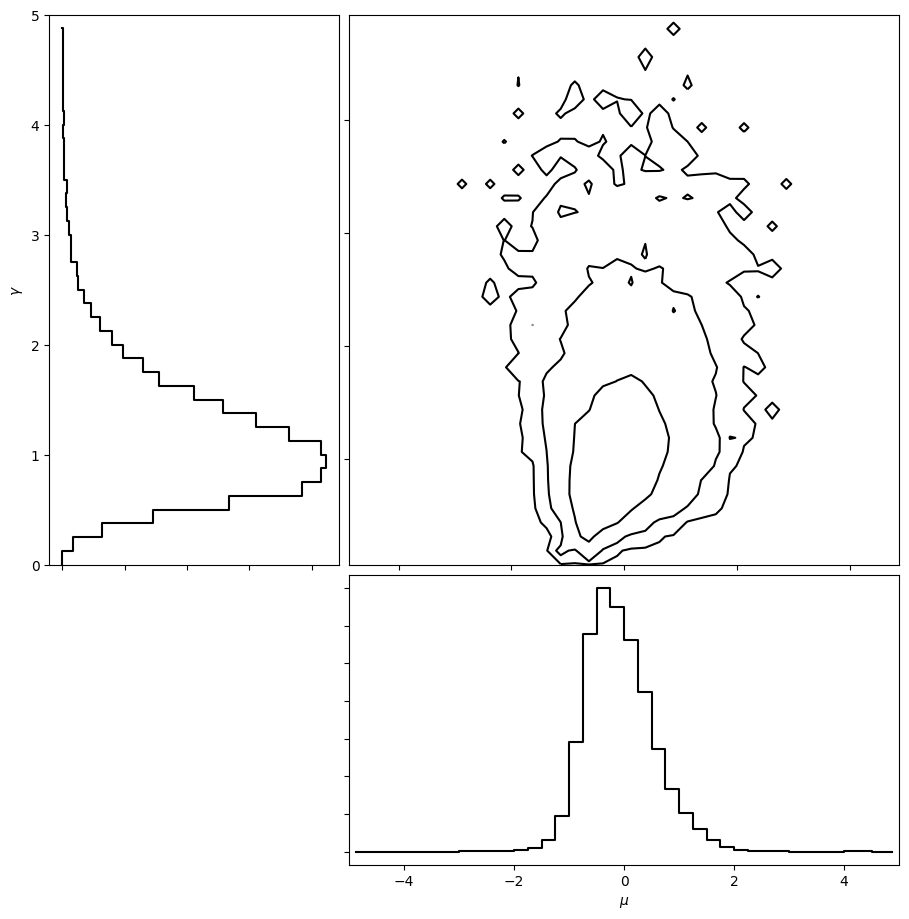

In [23]:
from astroML.plotting.mcmc import convert_to_stdev

# compute histogram of results to plot below
L_MCMC, mu_bins, gamma_bins = np.histogram2d(samples[:,0],
                                             np.exp(samples[:,1]),
                                             bins=(np.linspace(-5, 5, 41),
                                                   np.linspace(0, 5, 41)))
L_MCMC[L_MCMC == 0] = 1E-16  # prevents zero-division errors

hist_mu, bins_mu = np.histogram(samples[:,0], bins=mu_bins, density=True)
hist_gamma, bins_gamma = np.histogram(np.exp(samples[:,1]),
                                      bins=gamma_bins, density=True)
#----------------------------------------------------------------------
# plot the resultsq
fig = plt.figure(figsize=(10, 10))

# first axis: likelihood contours
ax1 = fig.add_axes((0.4, 0.4, 0.55, 0.55))
ax1.xaxis.set_major_formatter(plt.NullFormatter())
ax1.yaxis.set_major_formatter(plt.NullFormatter())
ax1.contour(0.5 * (mu_bins[:-1] + mu_bins[1:]),
            0.5 * (gamma_bins[:-1] + gamma_bins[1:]),
            convert_to_stdev(np.log(L_MCMC.T)),
            levels=(0.683, 0.955, 0.997),
            colors='k')

# second axis: marginalized over mu
ax2 = fig.add_axes((0.1, 0.4, 0.29, 0.55))
ax2.xaxis.set_major_formatter(plt.NullFormatter())
ax2.plot(hist_gamma, 0.5 * (bins_gamma[1:] + bins_gamma[:-1]
                            - bins_gamma[1] + bins_gamma[0]),
         '-k', drawstyle='steps')
ax2.set_ylabel(r'$\gamma$')
ax2.set_ylim(0, 5)

# third axis: marginalized over gamma
ax3 = fig.add_axes((0.4, 0.1, 0.55, 0.29))
ax3.yaxis.set_major_formatter(plt.NullFormatter())
ax3.plot(0.5 * (bins_mu[1:] + bins_mu[:-1]), hist_mu,
         '-k', drawstyle='steps-mid')
ax3.set_xlabel(r'$\mu$')
plt.xlim(-5, 5)

plt.show()

The contours denote 1,2, and 3-sigma credible regions, corresponding to  68.3%
 ,  95.5%
  and  99.7%
  probabilities.

I.e., we claim that our state of knowledge is such that we believe the true values of  𝜇,𝛾
  are enclosed by the 3rd contour with  99.7%
  confidence (and analogous for the inner-most and middle contour).

### And now with exact solution overplotted



In [24]:
def cauchy_logL(xi, sigma, mu):
    """Equation 5.74: cauchy likelihood"""
    xi = np.asarray(xi)
    n = xi.size
    shape = np.broadcast(sigma, mu).shape

    xi = xi.reshape(xi.shape + tuple([1 for s in shape]))

    return ((n - 1) * np.log(sigma)
            - np.sum(np.log(sigma ** 2 + (xi - mu) ** 2), 0))

In [25]:
# ----------------------------------------------------------------------
# Compute likelihood analytically for comparison
mu = np.linspace(-5, 5, 70)
gamma = np.linspace(0.1, 5, 70)
logL = cauchy_logL(xi, gamma[:, np.newaxis], mu)
logL -= logL.max()

p_mu = np.exp(logL).sum(0)
p_mu /= p_mu.sum() * (mu[1] - mu[0])

p_gamma = np.exp(logL).sum(1)
p_gamma /= p_gamma.sum() * (gamma[1] - gamma[0])

hist_mu, bins_mu = np.histogram(samples[:,0], bins=mu_bins, density=True)
hist_gamma, bins_gamma = np.histogram(np.exp(samples[:,1]),
                                      bins=gamma_bins, density=True)

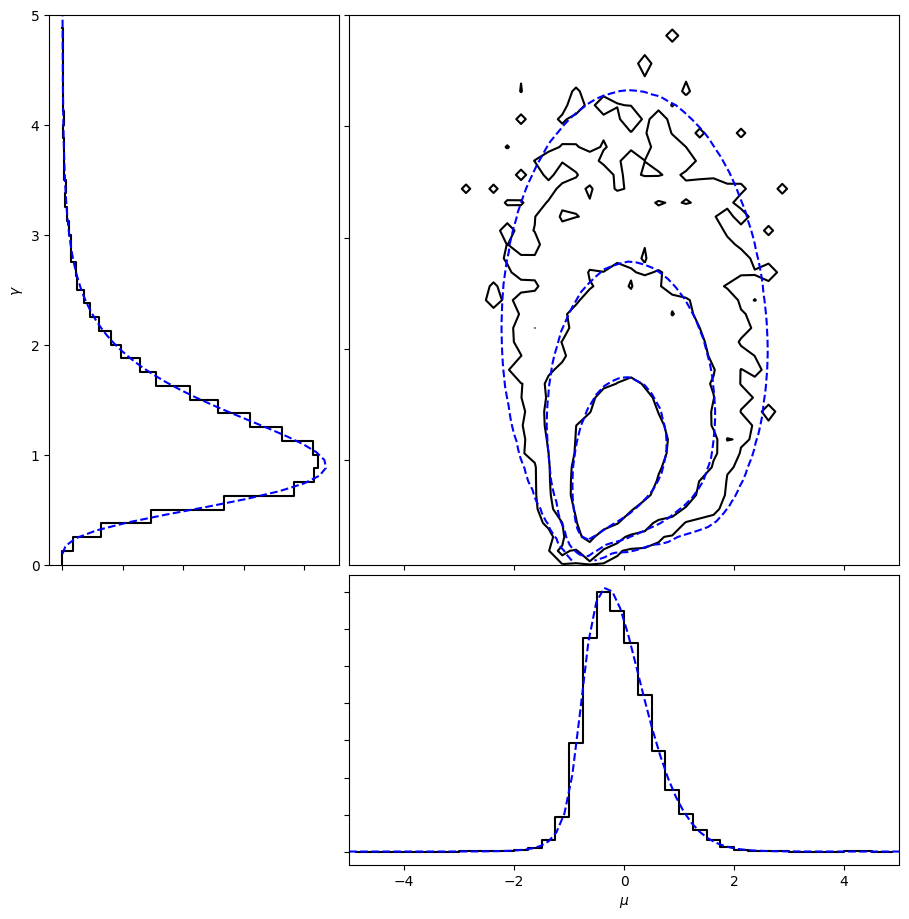

In [26]:
#----------------------------------------------------------------------
# plot the resultsq
fig = plt.figure(figsize=(10, 10))

# first axis: likelihood contours
ax1 = fig.add_axes((0.4, 0.4, 0.55, 0.55))
ax1.xaxis.set_major_formatter(plt.NullFormatter())
ax1.yaxis.set_major_formatter(plt.NullFormatter())
ax1.contour(0.5 * (mu_bins[:-1] + mu_bins[1:]),
            0.5 * (gamma_bins[:-1] + gamma_bins[1:]),
            convert_to_stdev(np.log(L_MCMC.T)),
            levels=(0.683, 0.955, 0.997),
            colors='k')
ax1.contour(mu, gamma, convert_to_stdev(logL),
            levels=(0.683, 0.955, 0.997),
            colors='b', linestyles='dashed')


# second axis: marginalized over mu
ax2 = fig.add_axes((0.1, 0.4, 0.29, 0.55))
ax2.xaxis.set_major_formatter(plt.NullFormatter())
ax2.plot(hist_gamma, 0.5 * (bins_gamma[1:] + bins_gamma[:-1]
                            - bins_gamma[1] + bins_gamma[0]),
         '-k', drawstyle='steps')
ax2.set_ylabel(r'$\gamma$')
ax2.set_ylim(0, 5)
ax2.plot(p_gamma, gamma, '--b')


# third axis: marginalized over gamma
ax3 = fig.add_axes((0.4, 0.1, 0.55, 0.29))
ax3.yaxis.set_major_formatter(plt.NullFormatter())
ax3.plot(0.5 * (bins_mu[1:] + bins_mu[:-1]), hist_mu,
         '-k', drawstyle='steps-mid')
ax3.set_xlabel(r'$\mu$')
plt.xlim(-5, 5)
ax3.plot(mu, p_mu, '--b')


plt.show()

##  Non-linear Regression with MCMC<a id='NLRmcmc'></a>
[Go to top](#toc)

### Non-linear regression: when the likelihood function is not a linear function of model parameters.  

### Example of non-linear regression: the age-color relation for asteroids

We will use age and color data for asteroid families shown in figure 1 from the paper 
"An age–colour relationship for main-belt S-complex asteroids" by Jedicke et al. (2004, Nature 429, 275), see http://faculty.washington.edu/ivezic/Publications/jedicke.pdf

Given their y(x) data (see below), with errors in both x and y, we want to fit the following function

$$ 𝑦(𝑥)=𝑎+𝑏∗[1−𝑒𝑥𝑝(−(𝑥/𝑐)^𝑑)]. $$

We have a case of non-linear regression because y(x) depends non-linearly on the 
unknown coefficients c and d.
 
Important: here x is time, not log(time)! But in plots we'll use log(time) for x axis.

We want to: 

a) find the best-fit values and standard errors for parameters a, b, c and d. 

b) show the marginal distributions of fitted parameters. 

c) compare our best fit to the best fit from Jedicke et al.  



In [27]:
%matplotlib inline
import numpy as np
from matplotlib import pyplot as plt 
# random seed 
np.random.seed(42)

In [28]:
# These age and color data for asteroid families are taken
# from the paper Jedicke et al. (2004, Nature 429, 275) 

# Age is measured in 10^6 yrs (Myr)
# Log10(age) and error (of Log(Age))
logAge = np.asarray([3.398, 2.477, 3.398, 3.477, 3.301, 1.699, 2.699, 0.763,
         2.301, 3.079,  3.176, 0.398])
LageErr = np.asarray([0.087, 0.145, 0.174, 0.145, 0.109, 0.347, 0.174, 0.015,
          0.217, 0.145, 0.145, 0.434])
# SDSS principal asteroid color PC1 and its error (per family)
PC1 = np.asarray([0.620, 0.476, 0.523, 0.582, 0.460, 0.479, 0.432, 0.351, 
       0.427, 0.522, 0.532, 0.311])
PC1err = np.asarray([0.005, 0.015, 0.007, 0.011, 0.005, 0.032, 0.033, 0.047,
        0.021, 0.015, 0.022, 0.027])
# time/age on linear axes
age = 10**logAge
# and standard error propagation (although errors can be large)
ageErr = age * LageErr * np.log(10)

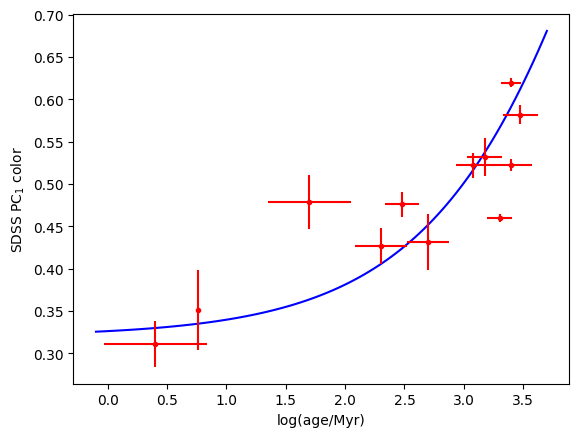

In [29]:
# let's take a quick look at the data to verify that it looks
# similar to fig. 1 from Jedicke et al. 
logT = np.linspace(-0.1, 3.7, 100)
time = np.power(10,logT)
# the best fit from Jedicke et al. 
color = 0.32 + 1.0*(1-np.exp(-(time/2.5e4)**0.5))
ax = plt.figure().add_subplot(111)
ax.set_xlabel("log(age/Myr)")
ax.set_ylabel("SDSS PC$_1$ color")
ax.plot(logT,color, c='blue')
ax.errorbar(logAge,PC1,xerr=LageErr, yerr=PC1err, color='r', 
             marker='.', ls='None', label='Observed')
plt.show() 

#### We will use pymc as the tool of choice to perform MCMC, see
[pymc docs](https://docs.pymc.io/)


I highly recommend to peruse this 
[excellent blog post by Jake VanderPlas](http://jakevdp.github.io/blog/2014/06/14/frequentism-and-bayesianism-4-bayesian-in-python/)

In [30]:
import pymc as pm
# from astroML.plotting.mcmc import plot_mcmc 

In [31]:
# to make it look more generic (for future code reuse)
xObs = age
xErr = ageErr
yObs = PC1
yErr = PC1err

In [32]:
# model to fit
def AgeColor(t, a, b, c, d):
    """age-color relationship from Jedicke et al. (2004)"""
    return a + b * (1 - np.exp(-(t / c) ** d))


# three points to make:
# 1) note setting of the priors (for a, b, c and d)
# 2) note how error in x is handled with a latent variable
# 3) the actual model that is fit is given by AgeColor() above
#      and it's super easy to change it! 
def MCMCasteroids(xObs, yObs, xErr, yErr, doXerror=True, draws=1000, tune=200):

    with pm.Model() as model:

        # 1) priors
        a = pm.Uniform('a', 0.1, 0.5)
        b = pm.Uniform('b', 0, 10)
        c = pm.Uniform('c', 0, 1_999_999)
        d = pm.Uniform('d', 0, 2)

        # 2) latent variable for x-error
        if doXerror:
            xLatent = pm.Normal('x', mu=xObs, sigma=xErr, shape=xObs.shape)
        else:
            xLatent = xObs

        # 3) likelihood
        mu = AgeColor(xLatent, a, b, c, d)

        y = pm.Normal('y', mu=mu, sigma=yErr, observed=yObs)

        # sampling (modern PyMC handles NUTS automatically)
        idata = pm.sample(draws=draws, tune=tune, random_seed=123, return_inferencedata=True)

    return idata

In [33]:
# obtain MCMC results
traces = MCMCasteroids(xObs, yObs, xErr, yErr, doXerror=True, draws=1000, tune=200)

# compute summary statistics
summary = az.summary(traces)

# best-fit parameters (posterior means)
bf = summary["mean"]

print(bf)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, c, d, x]


C:\Users\jacke\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\
Python313\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 200 tune and 1_000 draw iterations (800 + 4_000 draws total) took 46 seconds.
There were 2657 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


x[0]     3e+03
x[1]     4e+02
x[2]     1e+03
x[3]     3e+03
x[4]     5e+02
x[5]     8e+01
x[6]     5e+02
x[7]       5.7
x[8]     2e+02
x[9]     1e+03
x[10]    1e+03
x[11]        4
a         0.33
b          2.8
c        5e+05
d          0.5
Name: mean, dtype: str


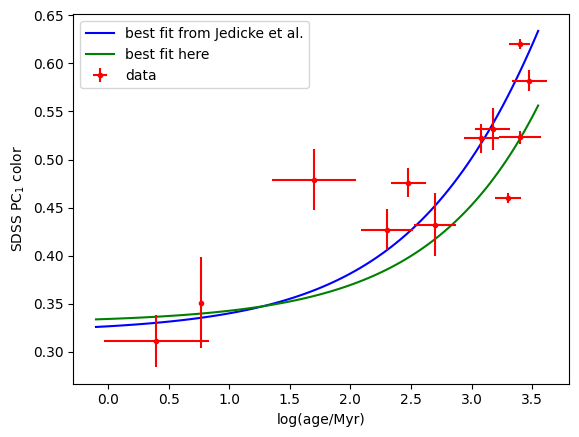

In [34]:
# let's take a look at the data and best-fit models 
logT = np.linspace(-0.1, 3.55, 100)
time = np.power(10,logT)

# fit from Jedicke
colorJedicke = AgeColor(time, 0.32, 1.0, 2.5e4, 0.5)

# best fit here
colorHere = AgeColor(
    time,
    float(bf["a"]),
    float(bf["b"]),
    float(bf["c"]),
    float(bf["d"])
)

# plot 
ax = plt.figure().add_subplot(111)
ax.set_xlabel("log(age/Myr)")
ax.set_ylabel("SDSS PC$_1$ color")
ax.plot(logT,colorJedicke, c='blue', label='best fit from Jedicke et al.')
ax.plot(logT,colorHere, c='green', label='best fit here')
ax.errorbar(logAge,PC1,xerr=LageErr, yerr=PC1err, color='r', marker='.', ls='None', label='data')
plt.legend()
plt.show() 

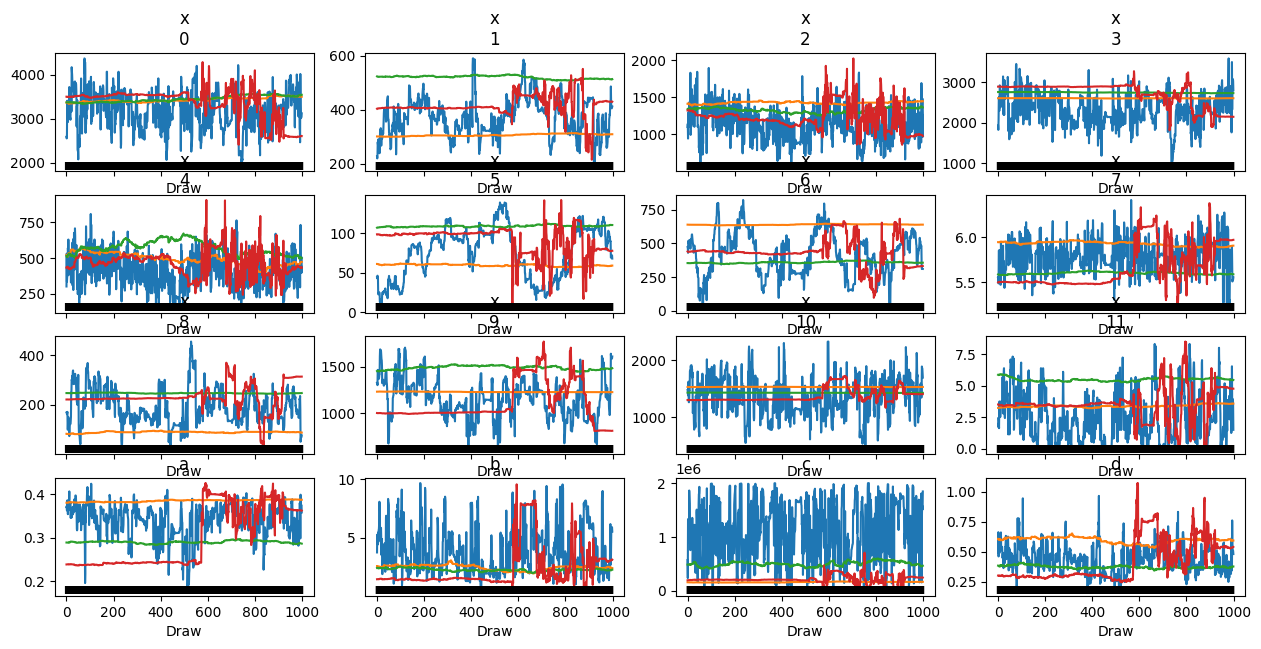

In [35]:
# the so-called traces for model parameters:
# plot = pm.traceplot(traces)
az.plot_trace(traces)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, c, d, x]


C:\Users\jacke\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\
Python313\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 114 seconds.
There were 22423 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


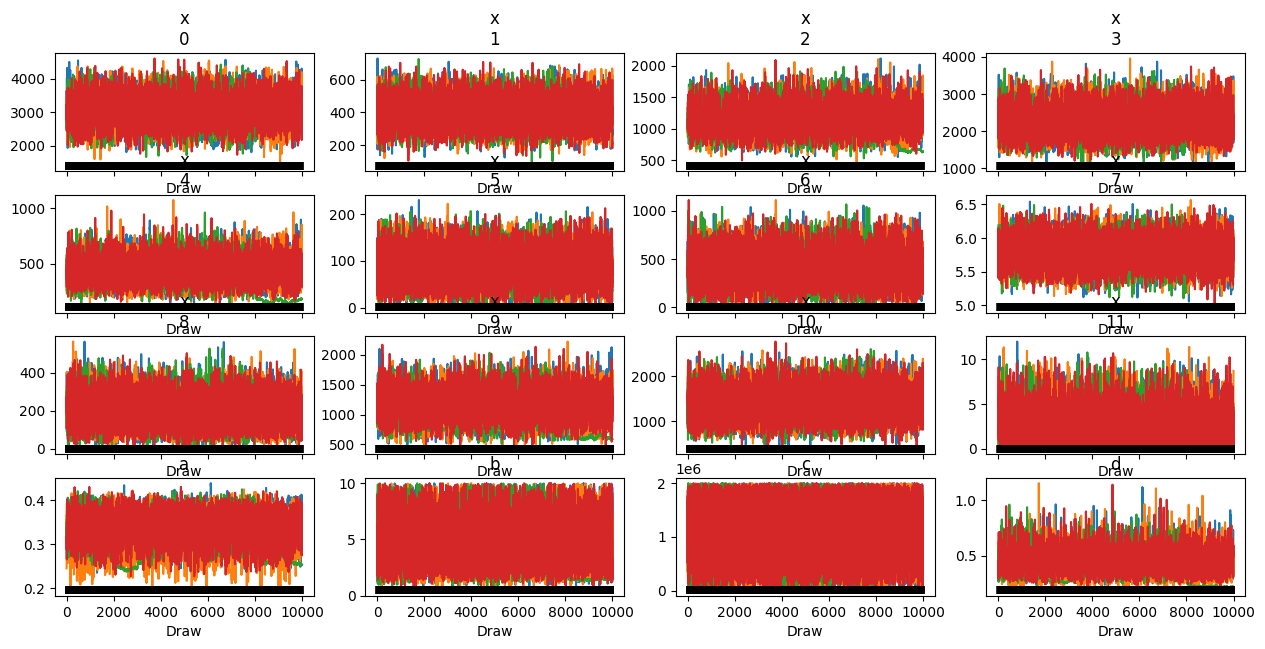

In [36]:
# repeat with longer chains
traces2 = MCMCasteroids(xObs, yObs, xErr, yErr, doXerror=True, draws=10000, tune=1000)
# compute summary statistics
summary2 = az.summary(traces2)
# best-fit parameters (posterior means)
bf2 = summary2["mean"]
az.plot_trace(traces2)

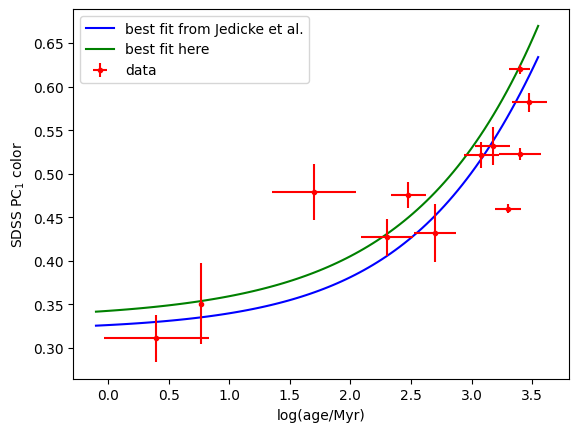

In [37]:
# let's take a look at the data and best-fit models 
colorHere2 = AgeColor(
    time,
    float(bf2["a"]),
    float(bf2["b"]),
    float(bf2["c"]),
    float(bf2["d"])
)


# plot 
ax = plt.figure().add_subplot(111)
ax.set_xlabel("log(age/Myr)")
ax.set_ylabel("SDSS PC$_1$ color")
ax.plot(logT,colorJedicke, c='blue', label='best fit from Jedicke et al.')
ax.plot(logT,colorHere2, c='green', label='best fit here')
ax.errorbar(logAge,PC1,xerr=LageErr, yerr=PC1err, color='r', marker='.', ls='None', label='data')
plt.legend()
plt.show() 

### use the famous "corner" plot for visualizing posteriors 

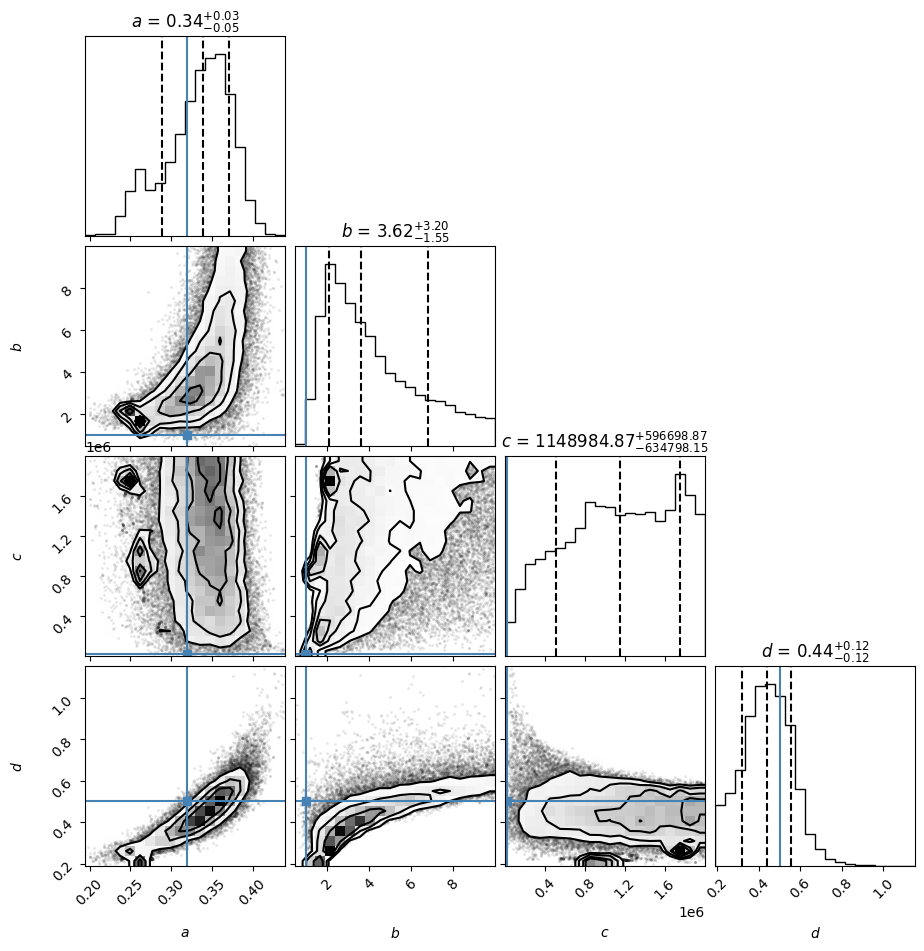

In [38]:
# extract posterior samples correctly
posterior2 = az.extract(
    traces2,
    group="posterior",
    var_names=["a", "b", "c", "d"]
)

samples2 = np.vstack([
    posterior2["a"].values,
    posterior2["b"].values,
    posterior2["c"].values,
    posterior2["d"].values
]).T

Ls = [r"$a$", r"$b$", r"$c$", r"$d$"] 
jedicke = [0.32, 1.0, 25000, 0.5]
limits = [(0.1, 0.55), (0.0, 12), (-100000,2200000), (0.1, 0.85)]


fig = corner.corner(
    samples2,
    truths=jedicke,
    labels=Ls,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 12}
)
plt.show()

# the end of Week 5

This is code copied from Week7 to test it during flight to Paris

In [39]:
# To remain consistent with the textbook, we'll use some functions that have 
# been deprecated in recent versions of astroML. This code silences the
# distracting deprecation warnings related to these.

import warnings
from astroML.utils.exceptions import AstroMLDeprecationWarning
warnings.filterwarnings("ignore", category=AstroMLDeprecationWarning)

In [40]:
# A utility function to convert the traces (chains) to a Pandas DataFrame
import pandas as pd
def traces_to_pandas(traces):
    varnames = [ var for var in traces.varnames if not var.endswith("_interval__") ]
    cols = { var: traces[var] for var in varnames }
    return pd.DataFrame(cols)

In [41]:
# Change these parameters to see what effect they have on how
# well the system can be modeled.
N = 100
b0_true = 10
A_true = 5
beta_true = 0.01
omega_true = 0.1
sigma = 2.0

# Ivezic, Figure 10.26
import numpy as np
from matplotlib import pyplot as plt

import scipy
import pymc as pm

from astroML.plotting.mcmc import plot_mcmc

def chirp(t, b0, beta, A, omega):
    return b0 + A * np.sin(omega * t + beta * t * t)

np.random.seed(0)

# Plot the functional form
t_tmp = np.linspace(0, 100, 10000)
y_tmp = chirp(t_tmp, b0_true, beta_true, A_true, omega_true)

# Generate the dataset, and overplot
t = np.sort(100 * np.random.random(N))
y_true = chirp(t, b0_true, beta_true, A_true, omega_true)
y_obs = np.random.normal(y_true, sigma)

def fig10_26():
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(14, 5), sharey=True)

    ax1.scatter(t, y_obs)
    ax1.set_ylabel("Flux (arbitrary units)")
    ax1.set_xlabel("t")
    ax1.set_title("Data only")

    ax2.plot(t_tmp, y_tmp, ls='--', color='gray')
    ax2.scatter(t, y_obs)
    ax2.set_xlabel("t")
    ax2.set_title("Data + truth")

    fig.tight_layout()

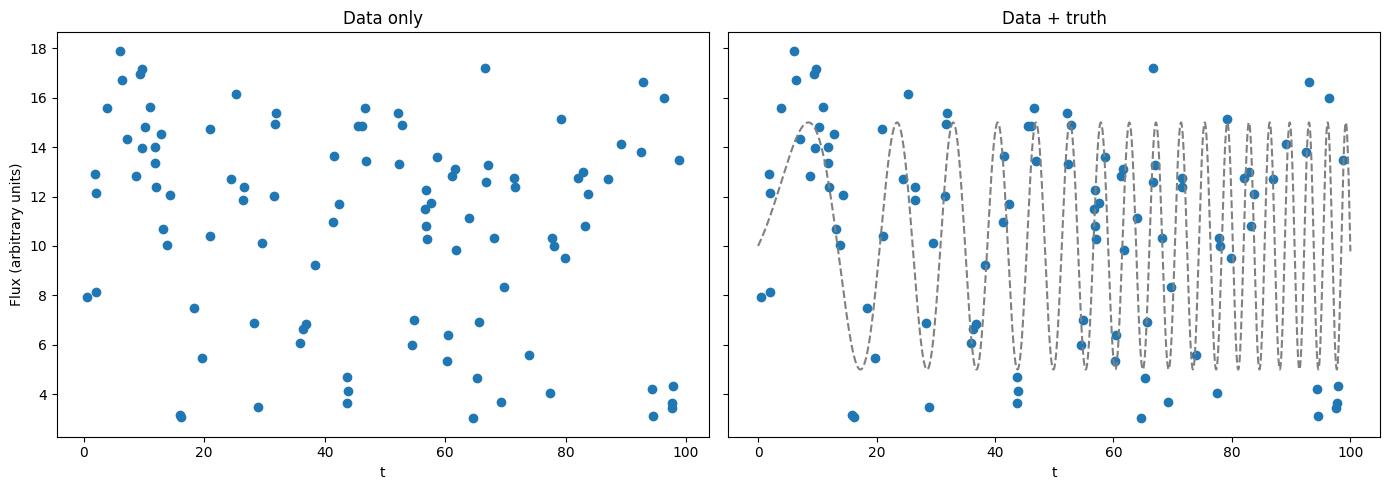

In [42]:
fig10_26()

In [43]:
# ----------------------------------------------------------------------
# Set up MCMC sampling
with pm.Model():
    b0 = pm.Uniform('b0', 0, 50, testval=50 * np.random.random())
    A = pm.Uniform('A', 0, 50, testval=50 * np.random.random())
    log_beta = pm.Uniform('log_beta', -10, 10, testval=-4.6)
    log_omega = pm.Uniform('log_omega', -10, 10, testval=-2.3)

    y = pm.Normal('y', mu=chirp(t, b0, np.exp(log_beta), A, np.exp(log_omega)),
                  sd=sigma, observed=y_obs)

    # Choose the Metropolis-Hastings step rather than rely on the default
    step = pm.Metropolis()
    traces = pm.sample(draws=5000, tune=2000, step=step)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [b0]
>Metropolis: [A]
>Metropolis: [log_beta]
>Metropolis: [log_omega]


C:\Users\jacke\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\
Python313\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 5_000 draw iterations (8_000 + 20_000 draws total) took 34 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [44]:
# summarize the results
df = traces_to_pandas(traces)
df["omega"] = np.exp(df['log_omega'])
df["beta"] = np.exp(df['log_beta'])
del df["log_beta"]
del df["log_omega"]

labels = ['$b_0$', '$A$', r'$\omega$', r'$\beta$']
limits = [(9.5, 11.3), (3.6, 6.4), (0.065, 0.115), (0.00975, 0.01045)]
true = [b0_true, A_true, omega_true, beta_true]

fig = plt.figure(figsize=(9, 9))
ax = plt.axes([0.5, 0.7, 0.45, 0.25])

# ----------------------------------------------------------------------
# Plot multiple panels with the traces
plt.scatter(t, y_obs, s=9, lw=0, c='k')

t_tmp = np.linspace(0, 100, 1001)
ax.plot(t_tmp, chirp(t_tmp, b0_true, beta_true, A_true, omega_true), '--', c='blue', label='true')
ax.plot(t_tmp, chirp(t_tmp, **df.median()), '-k', c='red', label='fit')
ax.legend()

plt.xlim(0, 100)
plt.xlabel('$t$')
plt.ylabel(r'$h_{\rm obs}$')

plot_mcmc([traces[ii] for ii in ['b0', 'A']]
          + [np.exp(traces['log_omega']), np.exp(traces['log_beta'])],
          labels=labels, limits=limits, true_values=true, fig=fig,
          bins=30, bounds=[0.12, 0.08, 0.95, 0.91], colors='k')
plt.show()

AttributeError: 'DataTree' object has no attribute 'varnames'

# here need to go back to chatGPT fixes and implement...

# let's try LS periodogram

In [45]:
#------------------------------------------------------------
# Generate Data
np.random.seed(42)
N = 100
P = 0.3

# simulate observations taken during nighttime
t = np.random.randint(100, size=N) + 0.3 + 0.4 * np.random.random(N)
y = 10 + np.sin(2 * np.pi * t / P)
dy = t*0 + 0.2
y_obs = np.random.normal(y, dy)

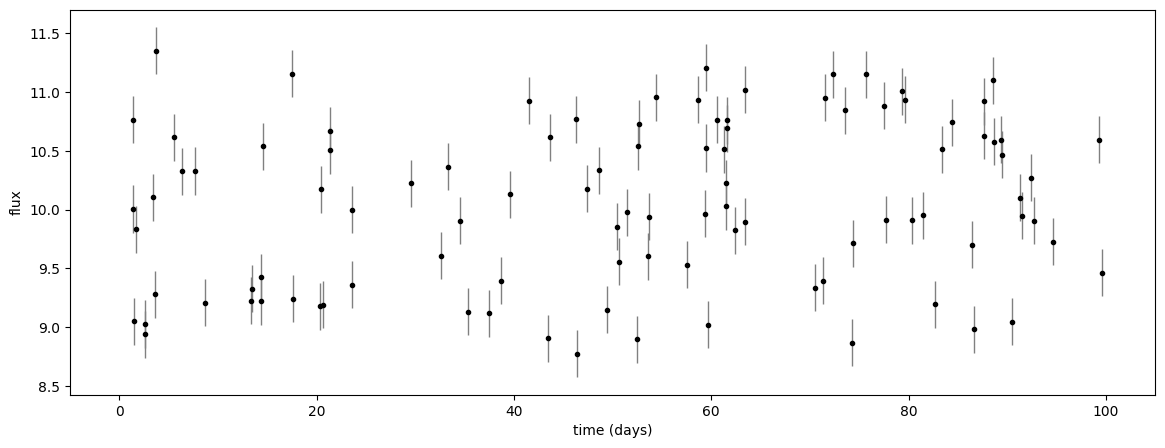

In [46]:
#------------------------------------------------------------
# Plot the results
fig, ax = plt.subplots(figsize=(14, 5))

ax.errorbar(t, y_obs, dy, fmt='.k', lw=1, ecolor='gray')
ax.set_xlabel('time (days)')
ax.set_ylabel('flux')
ax.set_xlim(-5, 105);

In [47]:
# Similar to Figure 10.15 in the textbook

def plot_phased(t, y_obs, P, ax = None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(14,7))

    phase = t / P - np.floor(t/P)
    ax.errorbar(phase, y_obs, dy, fmt='.k', lw=1, ecolor='gray')
    ax.set_xlabel('phase')
    ax.set_ylabel('flux')
    ax.set_xlim(-0.05, 1.05)
    
def plot_LS(t, y_obs, P_fit, sig1, sig5):
    #------------------------------------------------------------
    # Plot the results
    fig = plt.figure(figsize=(14, 7))
    fig.subplots_adjust(left=0.1, right=0.9, hspace=0.25)

    # First panel: the data
    ax = fig.add_subplot(211)
    plot_phased(t, y_obs, P_fit, ax=ax)

    # Second panel: the periodogram & significance levels
    ax1 = fig.add_subplot(212, xscale='log')
    ax1.plot(period, PS, '-', c='black', lw=1, zorder=1)
    ax1.plot([period[0], period[-1]], [sig1, sig1], ':', c='black', label="99% significance level")
    ax1.plot([period[0], period[-1]], [sig5, sig5], '-.', c='black', label="95% significance level")
    ax1.legend()

    ax1.annotate("", (P_fit, 0.95), (P_fit, 1.10), ha='center', arrowprops=dict(arrowstyle='->'))

    ax1.set_xlim(period[0], period[-1])
    ax1.set_ylim(-0.05, 1.15)

    ax1.set_xlabel(r'period (days)')
    ax1.set_ylabel('power')

    # Twin axis: label BIC on the right side
    ax2 = ax1.twinx()
    ax2.set_ylim(tuple(lomb_scargle_BIC(ax1.get_ylim(), y_obs, dy)))
    ax2.set_ylabel(r'$\Delta BIC$')

    ax1.xaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))
    ax1.xaxis.set_minor_formatter(plt.FormatStrFormatter('%.1f'))
    ax1.xaxis.set_major_locator(plt.LogLocator(10))
    ax1.xaxis.set_major_formatter(plt.FormatStrFormatter('%.3g'))

    plt.show()

In [48]:
from astroML.time_series import lomb_scargle, lomb_scargle_BIC, lomb_scargle_bootstrap

#------------------------------------------------------------
# Compute periodogram
period = 10 ** np.linspace(-1, 0, 10000)
omega = 2 * np.pi / period
PS = lomb_scargle(t, y_obs, dy, omega, generalized=True)

# find the highest peak
P_fit = period[PS.argmax()]

#------------------------------------------------------------
# Get significance via bootstrap
D = lomb_scargle_bootstrap(t, y_obs, dy, omega, generalized=True,
                           N_bootstraps=500, random_state=0)
sig1, sig5 = np.percentile(D, [99, 95])

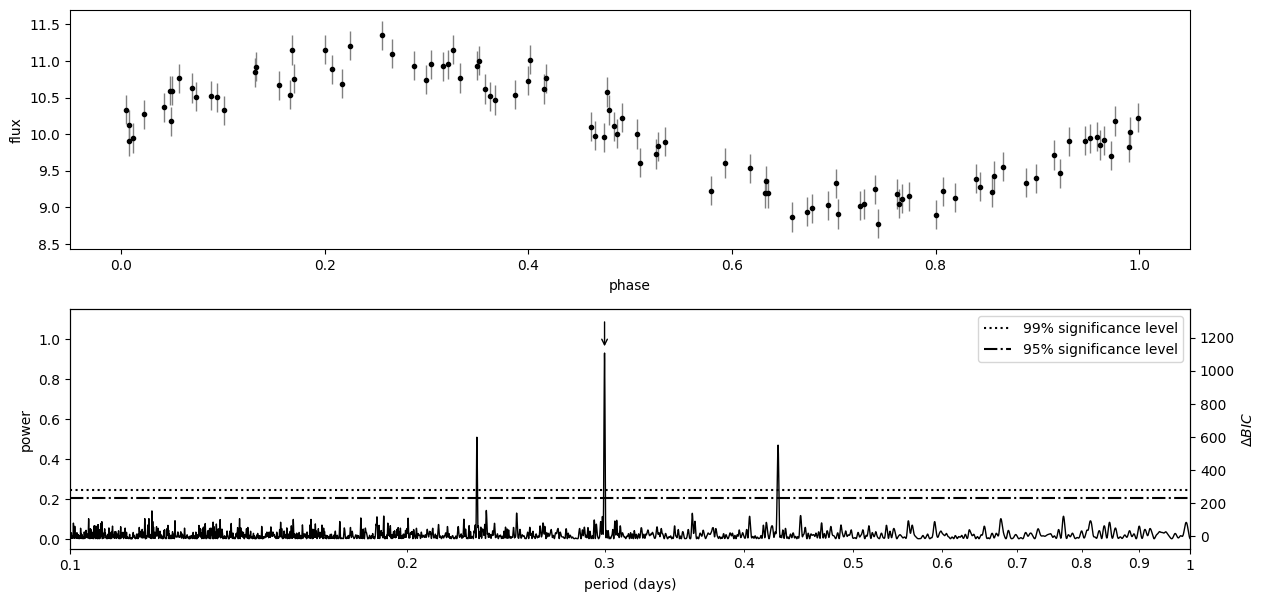

Location of highest periodogram peak, P_fit = 0.300 days


In [49]:
plot_LS(t, y_obs, P_fit, sig1, sig5)
print(f"Location of highest periodogram peak, P_fit = {P_fit:.3f} days")

In [50]:
from gatspy.datasets import fetch_rrlyrae

# Patch for changed URL
import gatspy.datasets.rrlyrae
gatspy.datasets.rrlyrae.SESAR_RRLYRAE_URL = 'https://github.com/astroML/astroML-data/raw/master/datasets/S82_RRLyr/'

rrlyrae = fetch_rrlyrae()
lcid = rrlyrae.ids[0]

t, y, dy, filts = rrlyrae.get_lightcurve(lcid)
period = rrlyrae.get_metadata(lcid)['P']

from gatspy.periodic import LombScargleMultiband
model = LombScargleMultiband(Nterms_base=1, Nterms_band=0)
model.fit(t, y, dy, filts)
periods = np.linspace(period - 0.1, period + 0.1, 2000)
power = model.periodogram(periods)

def plot_model(model, lcid):
    t, y, dy, filts = rrlyrae.get_lightcurve(lcid)
    model.fit(t, y, dy, filts)
    
    tfit = np.linspace(0, period, 1000)
    for filt in 'ugriz':
        mask = (filts == filt)
        eb = plt.errorbar(t[mask] % period, y[mask], dy[mask], fmt='.', label=filt)
        yfit = model.predict(tfit, filt, period=period)
        plt.plot(tfit, yfit, color=eb[0].get_color())
    plt.gca().invert_yaxis()
    plt.legend(ncol=3, loc='upper left')

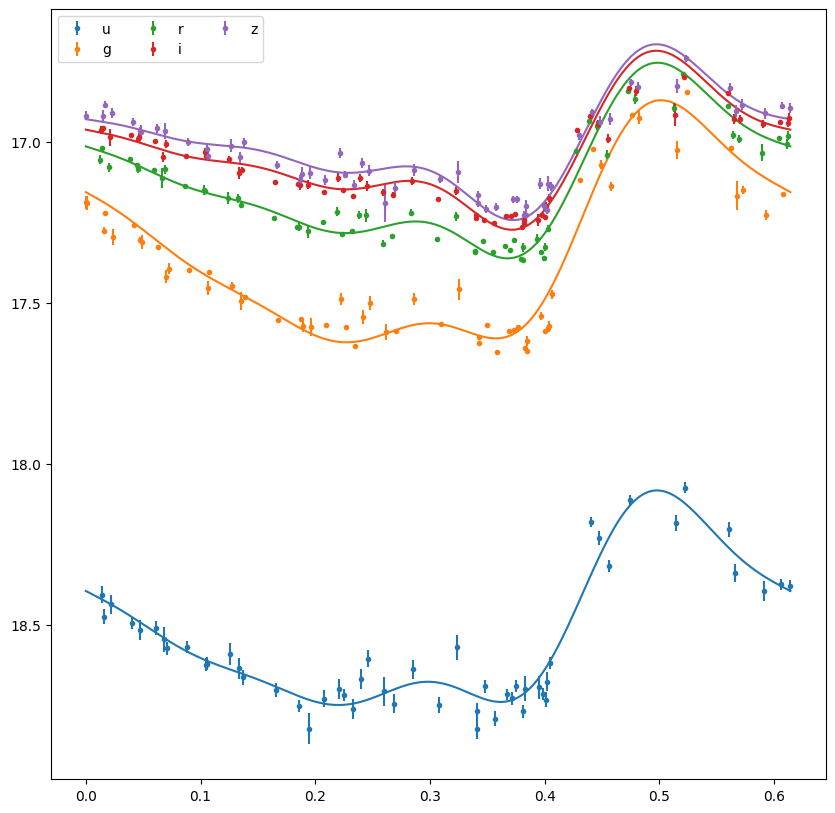

In [51]:
fig = plt.figure(figsize=(10,10))
plot_model(LombScargleMultiband(Nterms_base=4, Nterms_band=1), lcid)

# install gatspy! 